In [2]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar, precip_class)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot

## (1) Convective coverage

In [3]:
class calc_diag:
    def __init__(self,WRFFILELIST,trackdata,startindx,preslv,weshape,nsshape):
        self.WRFFILELIST = WRFFILELIST
        self.trackdata = trackdata
        self.startindx = startindx
        self.preslv = preslv
        self.weshape = weshape
        self.nsshape = nsshape

    def interp_to_preslv(self,vartointerp,prestointerp):
        nc_wp = [interplevel(vartointerp,prestointerp,i) for i in self.preslv]
        return np.asarray(nc_wp)
        
    def read_vars(self,varname):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            varout.append(getvar(Dataset(self.WRFFILELIST[i]),varname))
        return np.asarray(varout)

    def read_vars_and_interp(self,varname):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            vartointerp = getvar(Dataset(self.WRFFILELIST[i]),varname)
            prestointerp = getvar(Dataset(self.WRFFILELIST[i]),'pres')
            varout.append(self.interp_to_preslv(vartointerp,prestointerp))
        return np.asarray(varout)
        
    def find_track_ij(self):
        ixs,iys = [],[]
        for i, WRFFILE in tqdm(enumerate(self.WRFFILELIST)):
            # read file
            nc_ctrl = Dataset(WRFFILE)
            # Target location
            target_lat = self.trackdata['clat'][self.startindx+i] # Simulations start from 12 UTC
            target_lon = self.trackdata['clon'][self.startindx+i] # Simulations start from 12 UTC
            # Compute track indices
            ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
            ixs.append(int(ix.values))
            iys.append(int(iy.values))
        return ixs,iys
        
    def compute_tc_shear(self, u, v, x0, y0, dx_km=3.0,
                     inner_km=200.0, outer_km=800.0,
                     p_top=200.0, p_bot=850.0):
        """
        Compute mean 200–850 hPa shear vector in a TC-centered annulus.

        Parameters
        ----------
        ds : netCDF Dataset (opened with netCDF4 or xarray + wrf-python)
            WRF output file handle
        x0, y0 : int
            TC center grid indices (x,y) in WRF domain
        dx_km : float
            Grid spacing (km)
        inner_km, outer_km : float
            Inner and outer radius of annulus (km)
        p_top, p_bot : float
            Top and bottom pressure levels (hPa)

        Returns
        -------
        shear_u, shear_v : floats
            Zonal and meridional shear components (m/s)
        shear_mag : float
            Shear magnitude (m/s)
        """

        # --- Interpolate to levels
        u200 = u[self.preslv.index(p_top),...]
        v200 = v[self.preslv.index(p_top),...]
        u850 = u[self.preslv.index(p_bot),...]
        v850 = v[self.preslv.index(p_bot),...]

        # --- Make distance mask in km
        ny, nx = u200.shape
        X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
        dx = (X - x0) * dx_km
        dy = (Y - y0) * dx_km
        r = np.sqrt(dx**2 + dy**2)

        mask = (r >= inner_km) & (r <= outer_km)

        # --- Area-average wind in annulus
        u200m = np.nanmean(np.where(mask, u200, np.nan))
        v200m = np.nanmean(np.where(mask, v200, np.nan))
        u850m = np.nanmean(np.where(mask, u850, np.nan))
        v850m = np.nanmean(np.where(mask, v850, np.nan))

        # --- Shear vector
        shear_u = u200m - u850m
        shear_v = v200m - v850m
        shear_mag = np.sqrt(shear_u**2 + shear_v**2)

        return shear_u, shear_v, shear_mag

    def get_shear_mag_dir(self,Upres,Vpres,Xs,ys,settings=[200.0,800.0,200.0,850.0,3.0]):
        """
        settings = [inner_km,outer_km,p_top,p_bot,dx_km]
        """
        shear_mags,shear_dirs = [],[]
        shear_us, shear_vs = [],[]
        for i in range(len(Xs)):
            radiusshape = int(settings[1]/settings[4])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                shear_mags.append(np.nan)
                shear_dirs.append(np.nan)
                shear_us.append(np.nan)
                shear_vs.append(np.nan)
            else:
                shear_u, shear_v, shear_mag = self.compute_tc_shear(Upres[i,...], Vpres[i,...], Xs[i], ys[i], 
                                                                       dx_km=settings[4],
                                                                       inner_km=settings[0], outer_km=settings[1],
                                                                       p_top=settings[2], p_bot=settings[3])
                shear_mags.append(shear_mag)
                shear_dirs.append((np.degrees(np.arctan2(shear_v, shear_u)) % 360.0))
                shear_us.append(shear_u)
                shear_vs.append(shear_v)
        return shear_mags,shear_dirs, shear_vs, shear_us

    def data_to_TCcentre(self,data,Xs,ys,settings=[800.0,3.0,200.0]):
        dataTC = []
        for i in range(len(Xs)):
            radiusshape = int(settings[0]/settings[1])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                dataTC.append(np.nan)
            else:
                domainint = int(settings[2])
                dataTC.append(data[i,:,ys[i]-domainint:ys[i]+domainint,Xs[i]-domainint:Xs[i]+domainint])
        return np.asarray(dataTC)
            
    def data_to_polar(self,Cnc_wpz,dx,rmax,dr,nazim):        
        # Convert to polar coordinates
        # Suppose Xtrain_n shape = (n_samples, 9, ny, nx)
        ny, nx = Cnc_wpz.shape[-2:]
        if len(Cnc_wpz.shape)>3:
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpz, tri, pts, target_points, r, az)
        elif len(Cnc_wpz.shape)==3:
            Cnc_wpza = np.expand_dims(Cnc_wpz, axis=1)
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpza, tri, pts, target_points, r, az)

In [4]:
# Read function

def var_read(infile, varname):
    ncfile = Dataset(infile)
    var = ncfile.variables[varname][...]
    ncfile.close()
    var = np.squeeze(var)
    return var

def var_wrfread(infile, varname):
    disable_xarray()
    ncfile = Dataset(infile)
    var = getvar(ncfile, varname)
    ncfile.close()
    var = np.squeeze(var)
    return var

In [5]:
def get_precip_class(wrfout):
    # constants
    g = 9.8 # [m/s^2]
    # Read in hydrostatic pressure to get dp for integral
    p_hyd = var_read(wrfout,'P_HYD') # Pa
    p_hyd = np.ma.masked_where((p_hyd < 100e2), p_hyd, copy=False) # Mask out levels above 100 hPa
    nz, nj, ni = p_hyd.shape
    dp = np.gradient(p_hyd, axis=0, edge_order=1) # [Pa] Uses second order centered differencing

    # Read in and vertically integrate mixing ratios
    q_list = ['QCLOUD', 'QRAIN','QICE', 'QSNOW', 'QGRAUP']
    nvar = len(q_list)
    q_var = []
    for ivar in range(nvar):
        ivar = var_read(wrfout,q_list[ivar]) # kg/kg
        q_var.append(ivar)

    q_var = np.stack(q_var, axis=0)
    # Mass-weighted integral over full depth; yields kg/m^2 = mm (1/rho_water implicit)
    q_int = np.sum(q_var*dp, axis=1)/(-g)

    # Run classification
    c_type = precip_class.precip_class(q_int)
    #   0: non-precipitating
    # Convective:
    #   1: deep convective
    #   2: congestus
    #   3: shallow
    # Layered:
    #   4: stratiform
    #   5: anvil (weaker rainfall)
    return c_type

def area_stats(total, npts):
    return 1e2*total/npts

In [24]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:29]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
aiaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]

ra = 100 #radius (Nam et al. 2023)

ctrl_pclasses,miaxi2x_pclasses,dd_p2f_pclasses,aiaxi2x_pclasses,mdd_p2f_pclasses = [],[],[],[],[]
for i in tqdm(range(len(ctrl_files))):
    # read file
    nc_ctrl = Dataset(ctrl_files[i])
    # Target location
    target_lat = track_memb03['clat'][12+i]
    target_lon = track_memb03['clon'][12+i]
    # Compute track indices
    ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
    # Get Precip Class
    ctrl_pclass = get_precip_class(ctrl_files[i])[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra]
    miaxi2x_pclass = get_precip_class(miaxi2x_files[i])[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra]
    dd_p2f_pclass = get_precip_class(dd_p2f_files[i])[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra]
    mdd_p2f_pclass = get_precip_class(mdd_p2f_files[i])[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra]
    aiaxi2x_pclass = get_precip_class(aiaxi2x_files[i])[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra]

    # Derive axisymmetry
    ctrl_pclasses.append({'conv':area_stats(np.sum(ctrl_pclass==1), 4*ra*ra), 'strat':area_stats(np.sum(ctrl_pclass==4), 4*ra*ra),
                         'cong':area_stats(np.sum(ctrl_pclass==2),4*ra*ra), 'shal':area_stats(np.sum(ctrl_pclass==3),4*ra*ra),
                         'anvil':area_stats(np.sum(ctrl_pclass==5),4*ra*ra)})
    dd_p2f_pclasses.append({'conv':area_stats(np.sum(dd_p2f_pclass==1), 4*ra*ra), 'strat':area_stats(np.sum(dd_p2f_pclass==4), 4*ra*ra),
                           'cong':area_stats(np.sum(dd_p2f_pclass==2),4*ra*ra), 'shal':area_stats(np.sum(dd_p2f_pclass==3),4*ra*ra),
                           'anvil':area_stats(np.sum(dd_p2f_pclass==5),4*ra*ra)})
    mdd_p2f_pclasses.append({'conv':area_stats(np.sum(mdd_p2f_pclass==1), 4*ra*ra), 'strat':area_stats(np.sum(mdd_p2f_pclass==4), 4*ra*ra),
                            'cong':area_stats(np.sum(mdd_p2f_pclass==2),4*ra*ra), 'shal':area_stats(np.sum(mdd_p2f_pclass==3),4*ra*ra),
                            'anvil':area_stats(np.sum(mdd_p2f_pclass==5),4*ra*ra)})
    miaxi2x_pclasses.append({'conv':area_stats(np.sum(miaxi2x_pclass==1), 4*ra*ra), 'strat':area_stats(np.sum(miaxi2x_pclass==4), 4*ra*ra),
                            'cong':area_stats(np.sum(miaxi2x_pclass==2),4*ra*ra), 'shal':area_stats(np.sum(miaxi2x_pclass==3),4*ra*ra),
                            'anvil':area_stats(np.sum(miaxi2x_pclass==5),4*ra*ra)})
    aiaxi2x_pclasses.append({'conv':area_stats(np.sum(aiaxi2x_pclass==1), 4*ra*ra), 'strat':area_stats(np.sum(aiaxi2x_pclass==4), 4*ra*ra),
                            'cong':area_stats(np.sum(aiaxi2x_pclass==2),4*ra*ra), 'shal':area_stats(np.sum(aiaxi2x_pclass==3),4*ra*ra),
                            'anvil':area_stats(np.sum(aiaxi2x_pclass==5),4*ra*ra)})

    del nc_ctrl
    gc.collect()

100%|██████████| 29/29 [09:56<00:00, 20.56s/it]


In [22]:
np.sum(ctrl_pclass==1)

2570

In [25]:
pclassesdict = {'ctrl':ctrl_pclasses,'miaxi2x':miaxi2x_pclasses,'mdd_p2f':mdd_p2f_pclasses,'dd_p2f':dd_p2f_pclasses,'aiaxi2x':aiaxi2x_pclasses}
with open(f"./store/haiyansen_pclasses.pkl", "wb") as f:
    pickle.dump(pclassesdict, f)

In [8]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 10,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_21085/4003527188.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


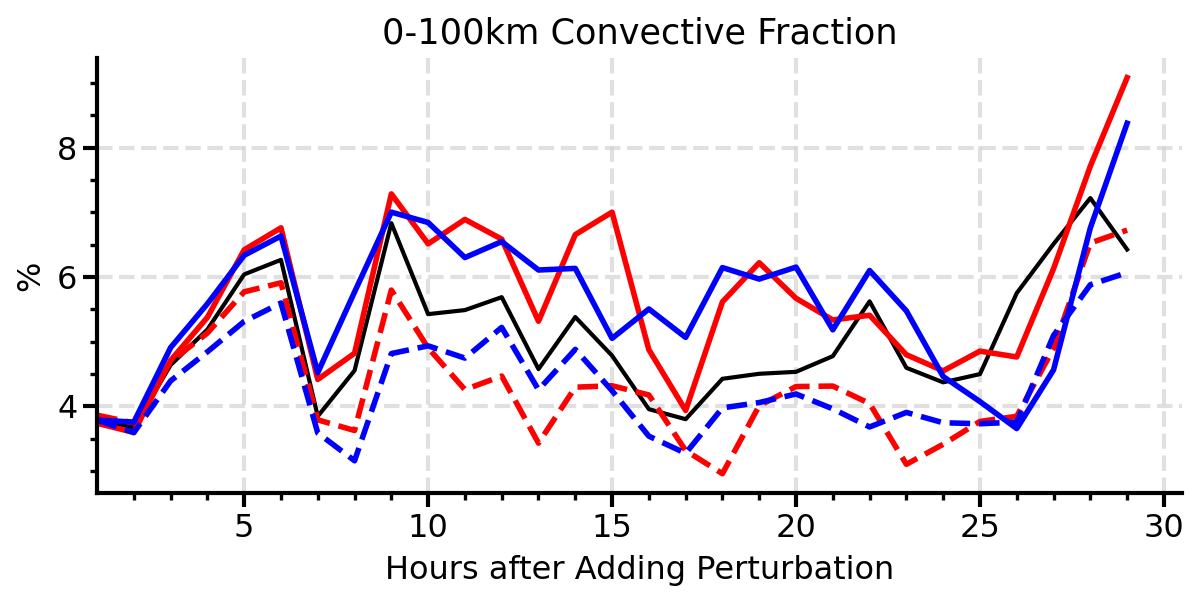

In [27]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in ctrl_pclasses],c='k',label='CTRL')
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in dd_p2f_pclasses],c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in mdd_p2f_pclasses],c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in aiaxi2x_pclasses],c='b',label='add_2IAXI',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in miaxi2x_pclasses],c='b',ls='--',label='minus_2IAXI',lw=2)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Convective Fraction',
           xlabel='Hours after Adding Perturbation', ylabel='%')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()

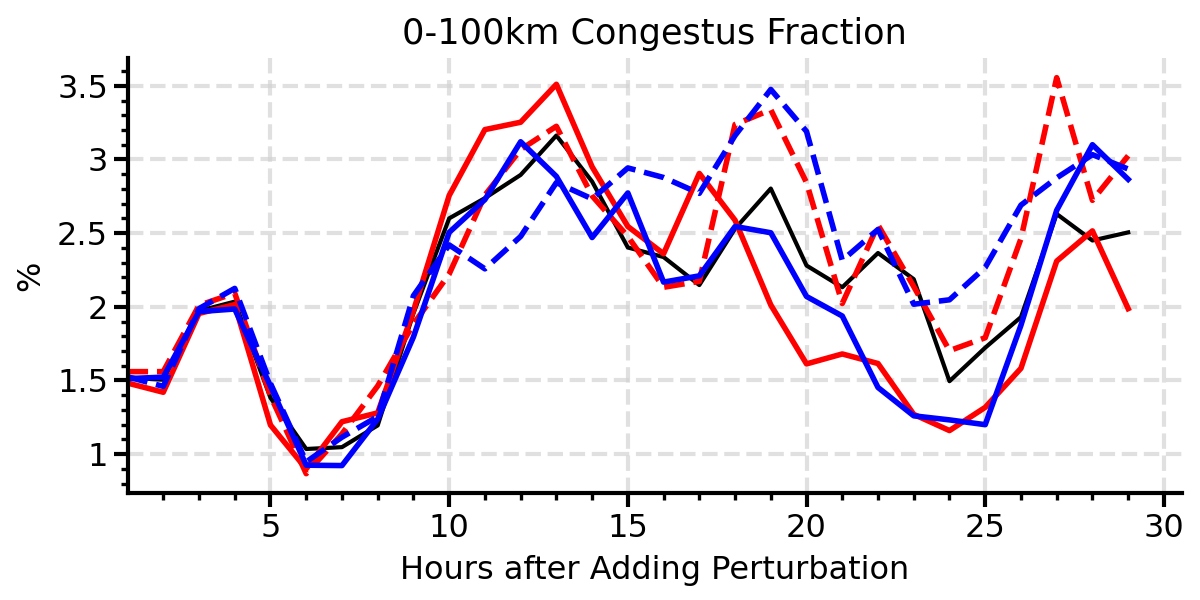

In [26]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['cong'] for obj in ctrl_pclasses],c='k',label='CTRL')
axs.plot(np.linspace(0,28,29)+1,[obj['cong'] for obj in dd_p2f_pclasses],c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['cong'] for obj in mdd_p2f_pclasses],c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['cong'] for obj in aiaxi2x_pclasses],c='b',label='add_2IAXI',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['cong'] for obj in miaxi2x_pclasses],c='b',ls='--',label='minus_2IAXI',lw=2)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Congestus Fraction',
           xlabel='Hours after Adding Perturbation', ylabel='%')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/cong_memb3.png',dpi=400)
plt.show()

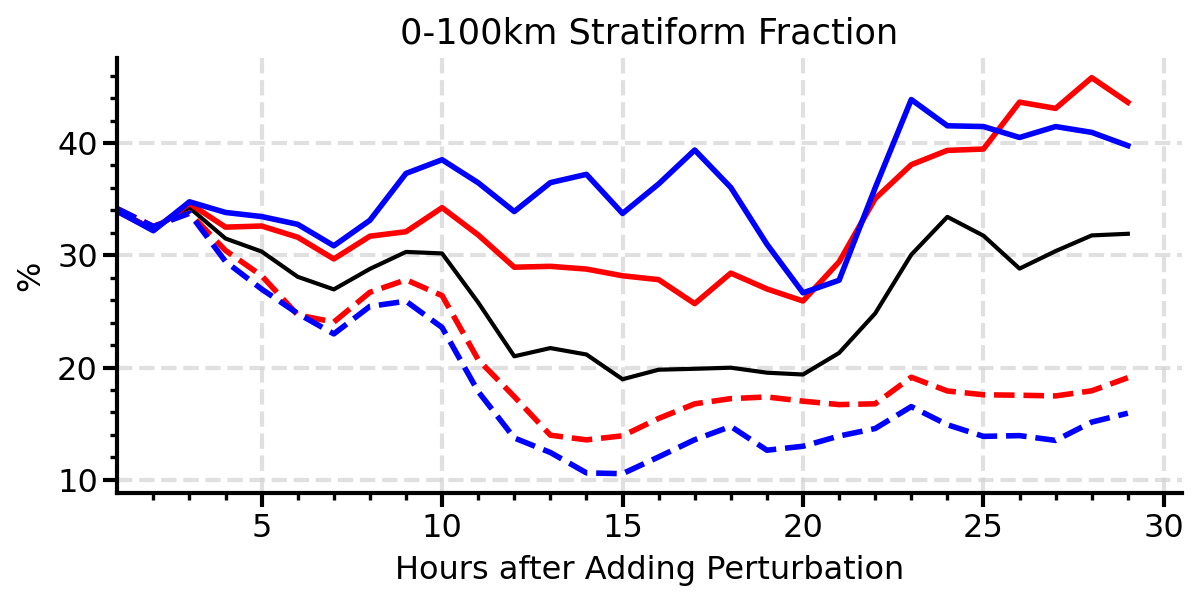

In [28]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in ctrl_pclasses],c='k',label='CTRL')
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in dd_p2f_pclasses],c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in mdd_p2f_pclasses],c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in aiaxi2x_pclasses],c='b',label='add_2IAXI',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in miaxi2x_pclasses],c='b',ls='--',label='minus_2IAXI',lw=2)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Stratiform Fraction',
           xlabel='Hours after Adding Perturbation', ylabel='%')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/strat_memb3.png',dpi=400)
plt.show()

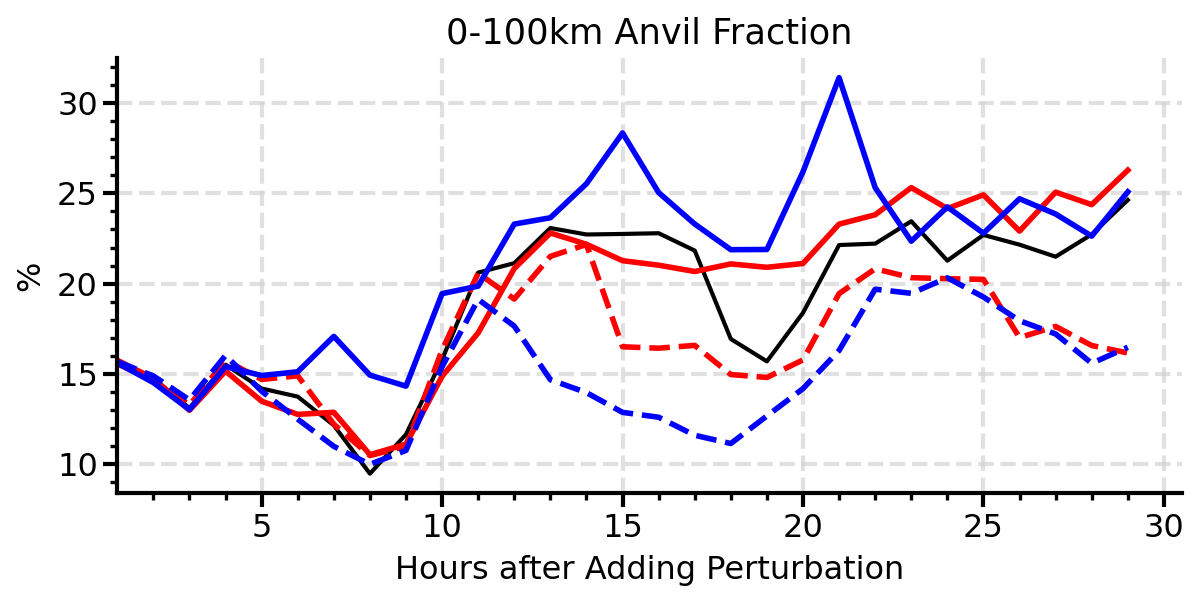

In [30]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['anvil'] for obj in ctrl_pclasses],c='k',label='CTRL')
axs.plot(np.linspace(0,28,29)+1,[obj['anvil'] for obj in dd_p2f_pclasses],c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['anvil'] for obj in mdd_p2f_pclasses],c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['anvil'] for obj in aiaxi2x_pclasses],c='b',label='add_2IAXI',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['anvil'] for obj in miaxi2x_pclasses],c='b',ls='--',label='minus_2IAXI',lw=2)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Anvil Fraction',
           xlabel='Hours after Adding Perturbation', ylabel='%')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/anvil_memb3.png',dpi=400)
plt.show()

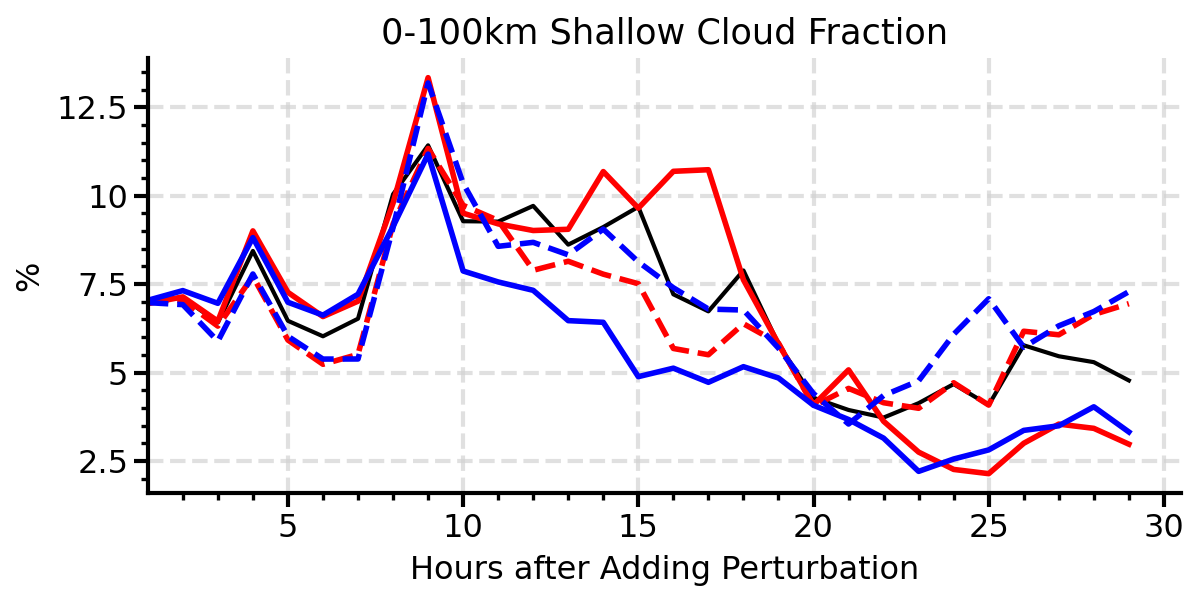

In [31]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['shal'] for obj in ctrl_pclasses],c='k',label='CTRL')
axs.plot(np.linspace(0,28,29)+1,[obj['shal'] for obj in dd_p2f_pclasses],c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['shal'] for obj in mdd_p2f_pclasses],c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['shal'] for obj in aiaxi2x_pclasses],c='b',label='add_2IAXI',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['shal'] for obj in miaxi2x_pclasses],c='b',ls='--',label='minus_2IAXI',lw=2)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Shallow Cloud Fraction',
           xlabel='Hours after Adding Perturbation', ylabel='%')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/shal_memb3.png',dpi=400)
plt.show()

In [26]:
print('Area fractions of each class:')
print()
area_stats('deep convective', np.sum(c_type==1), nj*ni)
area_stats('congestus', np.sum(c_type==2), nj*ni)
area_stats('shallow convective', np.sum(c_type==3), nj*ni)
area_stats('stratiform', np.sum(c_type==4), nj*ni)
area_stats('anvil', np.sum(c_type==5), nj*ni)
area_stats('all-precip', np.sum(c_type > 0), nj*ni)
area_stats('non-raining', np.sum(c_type==0), nj*ni)

Area fractions of each class:

number of deep convective points:  13725 ; domain fraction:  1.55 %
number of congestus points:  10550 ; domain fraction:  1.19 %
number of shallow convective points:  31298 ; domain fraction:  3.52 %
number of stratiform points:  71146 ; domain fraction:  8.01 %
number of anvil points:  54161 ; domain fraction:  6.1 %
number of all-precip points:  180880 ; domain fraction:  20.37 %
number of non-raining points:  707120 ; domain fraction:  79.63 %


### add_2WVN1

In [30]:
print('Area fractions of each class:')
print()
area_stats('deep convective', np.sum(c_type==1), nj*ni)
area_stats('congestus', np.sum(c_type==2), nj*ni)
area_stats('shallow convective', np.sum(c_type==3), nj*ni)
area_stats('stratiform', np.sum(c_type==4), nj*ni)
area_stats('anvil', np.sum(c_type==5), nj*ni)
area_stats('all-precip', np.sum(c_type > 0), nj*ni)
area_stats('non-raining', np.sum(c_type==0), nj*ni)

Area fractions of each class:

number of deep convective points:  13286 ; domain fraction:  1.5 %
number of congestus points:  11128 ; domain fraction:  1.25 %
number of shallow convective points:  32608 ; domain fraction:  3.67 %
number of stratiform points:  73366 ; domain fraction:  8.26 %
number of anvil points:  53567 ; domain fraction:  6.03 %
number of all-precip points:  183955 ; domain fraction:  20.72 %
number of non-raining points:  704045 ; domain fraction:  79.28 %


### minus_2WVN1

In [34]:
print('Area fractions of each class:')
print()
area_stats('deep convective', np.sum(c_type==1), nj*ni)
area_stats('congestus', np.sum(c_type==2), nj*ni)
area_stats('shallow convective', np.sum(c_type==3), nj*ni)
area_stats('stratiform', np.sum(c_type==4), nj*ni)
area_stats('anvil', np.sum(c_type==5), nj*ni)
area_stats('all-precip', np.sum(c_type > 0), nj*ni)
area_stats('non-raining', np.sum(c_type==0), nj*ni)

Area fractions of each class:

number of deep convective points:  14350 ; domain fraction:  1.62 %
number of congestus points:  11412 ; domain fraction:  1.29 %
number of shallow convective points:  31952 ; domain fraction:  3.6 %
number of stratiform points:  73865 ; domain fraction:  8.32 %
number of anvil points:  54529 ; domain fraction:  6.14 %
number of all-precip points:  186108 ; domain fraction:  20.96 %
number of non-raining points:  701892 ; domain fraction:  79.04 %


In [ ]:
sens2x_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add2wv1N/wrfout_d02_2013-11-0*"))[:30]
ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:30]
#sens1x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_wv1N/wrfout_d02_2013-11-0*"))[:30]
minus2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/minus_2wv1N/wrfout_d02_2013-11-0*"))[:30]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:30]

etalevels,weshape,nsshape = getvar(Dataset(ctrl_files[-1]),'pres').shape
wrfdiags = calc_diag(ctrl_files,track_memb03,12,[10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000],weshape,nsshape)
tracks_ij = wrfdiags.find_track_ij()